# Dataset Curation 

some of our dft calculations could have gone wrong. The way to filter this is through the E-V curves for each sample. 

# 
- input : non curated bs
- output: curated bs regarding ev curves

TODO: bopio and bopcal needed for featurizer ! separate package for bopfox ?

## check ev-curves for goodness

In [1]:
import sys
#sys.path.insert(0,'/home/storage/fortimtb/DatasetsML/Tools/')
sys.path.insert(0,'/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')
dataset = 'Cr-Co-W' #'Fe-Mo/'
atoms = dataset.split('-')
from Tools.DatasetTools.EVCurvesTools import *
from BopFoxFeaturizer.Featurizer import Featurizer
import pickle
import os

In [2]:
plt.rc('figure', figsize=(12,8))
plt.rc('font', size=22)

In [3]:
def get_key_for_curves(EVC: pd.core.series.Series, key='str') -> pd.core.series.Series:
    r2 = {}
    for index, data in EVC.items():
        r2[index]={}
        for params, curve in data.items():
            r2[index].update({params: curve[key]})
    return pd.Series(r2)
    

In [4]:
PBS = pd.read_pickle(os.path.join(dataset, 'ParsedBriefsummary.pkl'))

## Investigate ev-curves

In [5]:
fittedcurvesloc = os.path.join(dataset, 'evcurvesfitted.json')
evcurvesloc = os.path.join(dataset,'evcurves.json' )
goodnessloc = os.path.join(dataset, 'goodness.json')
if not os.path.exists(fittedcurvesloc):
    if not os.path.exists(evcurvesloc):
        EV = Evcurves(Indexes = PBS.index, atoms=['Fe','Mo'], dataset = dataset)#, search_str='**/volume_relaxed/**/volume-energy.dat')
        EV.load_evcurves( deltaks = PBS['deltak'], encuts = PBS['encut'])
        EVcurves = EV.evcurves
        EVcurves.to_json(evcurvesloc)
    else:
        EVcurves = pd.read_json(evcurvesloc, typ='series')
    goodness, fiteos, r2  = get_goodness(EVcurves)
    if goodness.map(lambda g: False in g.values()).all():
        goodness = invert_goodness(goodness)
    Goodness = pd.Series(goodness)
    Fits = pd.Series(fiteos)
    R2 = pd.Series(r2)
    for index, data in EVcurves.items():
        for key, evcurve in data.items():
            data[key].update({'r2': R2[index][key], 'fit': Fits[index][key], 'IsGood': Goodness[index][key]})
    EVcurves.to_json(fittedcurvesloc)
else:
    EVcurves = pd.read_json(fittedcurvesloc, typ='series')
    R2 = get_key_for_curves(EVcurves, 'r2')
    Goodness = get_key_for_curves(EVcurves, 'IsGood')
    Fits = get_key_for_curves(EVcurves, 'fit')

In [6]:
indexofgoodsamples = []
for index, data in EVcurves.items():
    for params, evcurve in data.items():
        if  evcurve['IsGood']:
            indexofgoodsamples.append(index)
indexofgoodsamples = pd.Index(indexofgoodsamples)

In [7]:
GoodBS = PBS.loc[indexofgoodsamples]
BadBS = PBS.loc[PBS.index.difference(indexofgoodsamples)]

GoodBS = GoodBS[~GoodBS.index.str.contains('sigma-BABBB.FM|sigma-AABBB.FM|mu-BBBBA.FM')]

## Remove extra magnetic sampling

First feature to remove from this dataset is the list of samples used form ferrimagnetic phase sampling. This subset is not in the current interest and might bring problems so we remove from datastet.

In [8]:
GoodBS = GoodBS.loc[~GoodBS.index.str.contains('\..*[UD]+$') ]

## Obtain some info from indexes

In [9]:
Features = Featurizer(GoodBS)

In [10]:
GoodBS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,atom_C,num_atom_A,num_atom_B,num_atom_C,num_atoms,Co_pv,Cr_pv,W_sv,EF
Co_pv6W_sv6.C14-BBA.FM,bulk C14-BBA.FM,13.175678 A,-10.000427,293.907391 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,2,...,W_sv,,6,6,0,12.0,0.500000,0.000000,0.500000,-0.008728
Co_pv6W_sv6.C14-BBA.NM,bulk C14-BBA,13.175679 A,-10.000427,293.949578 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,2,...,W_sv,,6,6,0,12.0,0.500000,0.000000,0.500000,-0.008728
Cr_pv6W_sv2.D0_19-A3B.FM,bulk D0_19-A3B.FM,13.098145 A,-10.002413,244.993002 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,2,...,W_sv,,6,2,0,8.0,0.000000,0.750000,0.250000,0.36766
Cr_pv6W_sv2.D0_19-A3B.NM,bulk D0_19-A3B,13.093819 A,-10.002452,248.338396 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,2,...,W_sv,,6,2,0,8.0,0.000000,0.750000,0.250000,0.367621
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,bulk sigma-CBAAC.FM,13.525828 A,-10.003732,243.415325 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,3,...,Co_pv,W_sv,16,4,10,30.0,0.133333,0.533333,0.333333,0.322855
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cr_pv10W_sv3.mu-BAAAB.FM,bulk mu-BAAAB.FM,13.271764 A,-9.986312,205.612028 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,2,...,W_sv,,10,3,0,13.0,0.000000,0.769231,0.230769,0.317515
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,bulk sigma-BAACA,13.189913 A,-9.988760,251.071094 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,3,...,Co_pv,W_sv,20,2,8,30.0,0.066667,0.666667,0.266667,0.27345
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,bulk sigma-BAACA.FM,13.189987 A,-9.988760,251.093896 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,3,...,Co_pv,W_sv,20,2,8,30.0,0.066667,0.666667,0.266667,0.27345
Co_pv13W_sv16.chi-ABAB.NM,bulk chi-ABAB,14.051746 A,-9.988843,263.749012 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,2,...,W_sv,,13,16,0,29.0,0.448276,0.000000,0.551724,0.309268


## translate structures to their bases

# TODo this sould be in tools, as a phase cleaner

In [11]:
from BopFoxFeaturizer.struct_db import struct_db
#struct_db = SourceFileLoader('struct_db','BopFoxFeaturizer/struct_db.py').load_module().struct_db
strucdic = struct_db().strucstrings

Target_Class = pd.Series(
    GoodBS.index.str.split('.').map(lambda l: l[1]).map(lambda s: s.split('-')[0]),
    index=GoodBS.index
)
Target_Class[Target_Class.map(lambda s: s in strucdic['list.hcp'])]='hcp'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.fcc'])]='fcc'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.bcc'])]='bcc'
Target_Class[Features.Struc == 'hcp'] = 'hcp'
Target_Class[Features.Struc == 'bcc'] = 'bcc'
Target_Class[Features.Struc == 'fcc'] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-fcc')] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-L12')] = 'fcc'
Target_Class[Features.Struc.str.contains('sigma_')] = 'sigma'

Target_Class[    
    Target_Class.str.contains('Al42W') |\
    Target_Class.str.contains('Al9Co2') |\
    Target_Class.str.contains('Al5W') |\
    Target_Class.str.contains('Al12W') |\
    Target_Class.str.contains('Al4W') |\
    Target_Class.str.contains('Al5Co2')
] = 'others'

In [12]:
Target_Class

Co_pv6W_sv6.C14-BBA.FM                  C14
Co_pv6W_sv6.C14-BBA.NM                  C14
Cr_pv6W_sv2.D0_19-A3B.FM                hcp
Cr_pv6W_sv2.D0_19-A3B.NM                hcp
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM    sigma
                                      ...  
Cr_pv10W_sv3.mu-BAAAB.FM                 mu
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM     sigma
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM     sigma
Co_pv13W_sv16.chi-ABAB.NM               chi
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.NM    sigma
Length: 1701, dtype: object

In [13]:
GoodBS['Phase'] = Target_Class

In [14]:
GoodBS.describe()

,E0,nelem,B0,V0,num_atoms,Co_pv,Cr_pv,W_sv
count,1701.000000,1701.000000,1701.000000,1701.000000,1701.000000,1701.000000,1701.000000,1701.000000
mean,-9.585216,2.541446,250.548597,13.203339,21.965315,0.323785,0.340741,0.335473
std,1.188574,0.561682,22.528036,1.499822,8.686398,0.244977,0.250990,0.243910
min,-12.953686,1.000000,104.539707,10.314702,1.000000,0.000000,0.000000,0.000000
25%,-10.378787,2.000000,237.019893,11.955027,13.000000,0.153846,0.153846,0.153846
50%,-9.524625,3.000000,252.629633,13.059967,24.000000,0.307692,0.333333,0.307692
75%,-8.758552,3.000000,264.325020,14.353720,30.000000,0.500000,0.533333,0.500000
max,-6.504079,3.000000,458.517772,16.955051,53.000000,1.000000,1.000000,1.000000


# some E-V curves, good and bad

In [15]:
sample_bad = EVcurves[BadBS.index].dropna().sample(n=5)

In [16]:
sample_bad

Co_pv4W_sv9.mu-BBAAB.FM             {'xc=PBE-PAW.E=400.dk=0.020': {'evcurve': {'V'...
Cr_pv14Co_pv10.C36-AABBA.FM         {'xc=PBE-PAW.E=400.dk=0.020': {'evcurve': {'V'...
Co_pv4W_sv8.C14-ABB.FM              {'xc=PBE-PAW.E=400.dk=0.020': {'evcurve': {'V'...
Cr_pv4Co_pv10W_sv10.C36-BACCB.FM    {'xc=PBE-PAW.E=400.dk=0.020': {'evcurve': {'V'...
Co_pv4W_sv9.mu-BBBAA.FM             {'xc=PBE-PAW.E=400.dk=0.020': {'evcurve': {'V'...
dtype: object

In [17]:
plt.rc('font', size=22)
plt.rc('figure', figsize=(12,8))

In [18]:
sample_bad_r2 = R2[sample_bad.index]

In [19]:
sample_bad_fit = Fits[sample_bad.index]

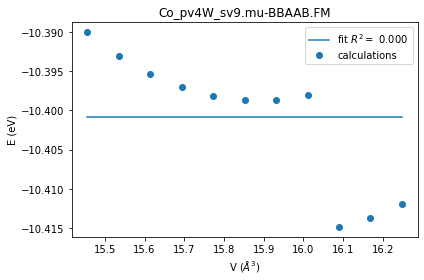

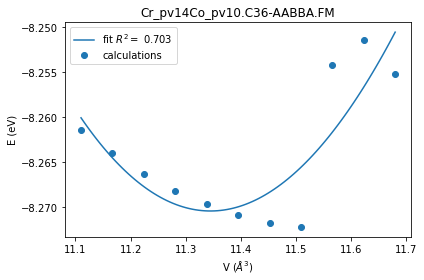

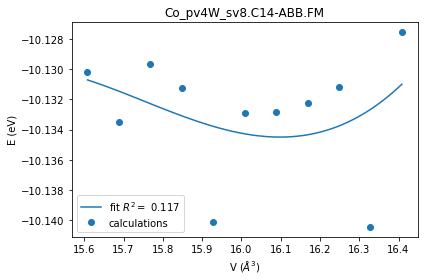

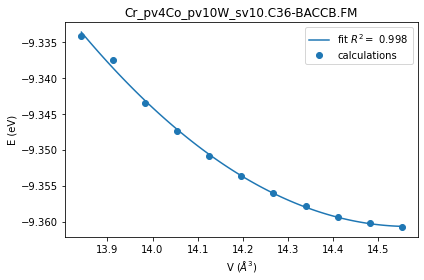

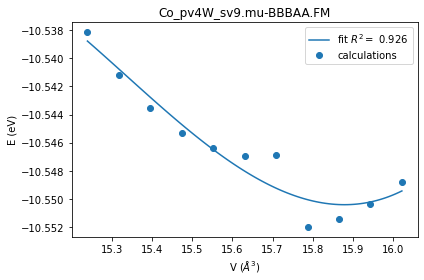

In [20]:
figurecollection, axcollection  = plot_curves(sample_bad, sample_bad_fit, sample_bad_r2)

In [21]:
sample_good = EVcurves[GoodBS.index].dropna().sample(n=5)

In [22]:
sample_good

Cr_pv2Co_pv20W_sv8.sigma-ABCBB.FM    {'xc=PBE-PAW.E=400.dk=0.020': {'evcurve': {'V'...
Cr_pv10W_sv20.sigma-ABABB.FM         {'xc=PBE-PAW.E=400.dk=0.020': {'evcurve': {'V'...
W_sv13.mu.NM                         {'xc=PBE-PAW.E=400.dk=0.020': {'evcurve': {'V'...
Cr_pv2Co_pv6.A15-BA.FM               {'xc=PBE-PAW.E=400.dk=0.020': {'evcurve': {'V'...
Cr_pv14Co_pv8W_sv8.sigma-AACBA.FM    {'xc=PBE-PAW.E=400.dk=0.020': {'evcurve': {'V'...
dtype: object

In [23]:
Goodness[sample_good.index]

Cr_pv2Co_pv20W_sv8.sigma-ABCBB.FM    {'xc=PBE-PAW.E=400.dk=0.020': True}
Cr_pv10W_sv20.sigma-ABABB.FM         {'xc=PBE-PAW.E=400.dk=0.020': True}
W_sv13.mu.NM                         {'xc=PBE-PAW.E=400.dk=0.020': True}
Cr_pv2Co_pv6.A15-BA.FM               {'xc=PBE-PAW.E=400.dk=0.020': True}
Cr_pv14Co_pv8W_sv8.sigma-AACBA.FM    {'xc=PBE-PAW.E=400.dk=0.020': True}
dtype: object

In [24]:
sample_good_r2 = R2[sample_good.index]

In [25]:
sample_good_fit = Fits[sample_good.index]

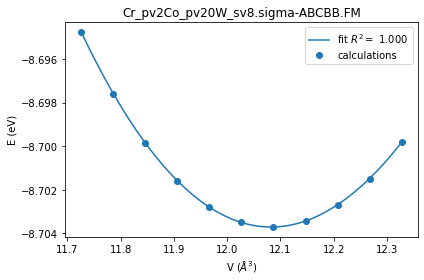

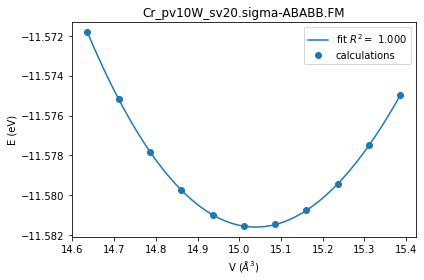

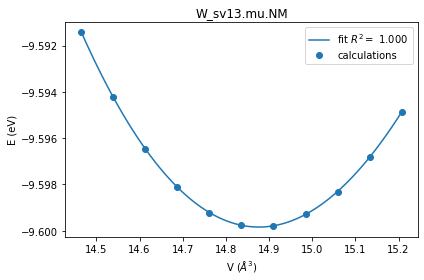

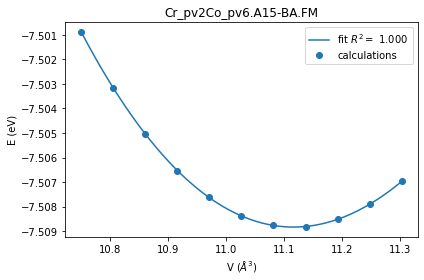

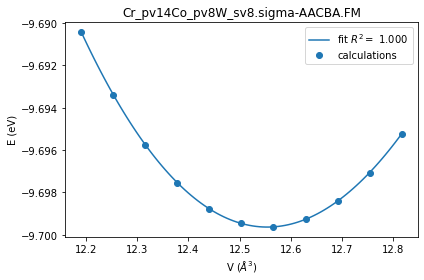

In [26]:
figurecollection, axcollection  = plot_curves(sample_good, sample_good_fit, sample_good_r2)

still high and low B0s

<AxesSubplot:>

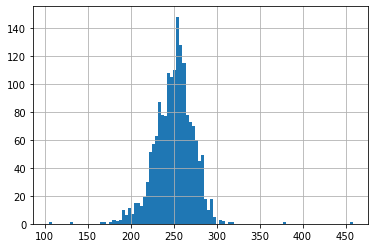

In [27]:
GoodBS.B0.hist(bins=100)

In [28]:
sample_max_B0 = GoodBS[GoodBS.nelem==1].B0.idxmax()

In [29]:
sample_max_B0

'W_sv1.bcc.NM'

In [30]:
sample_min_B0 = GoodBS[GoodBS.nelem==1].B0.idxmin()

In [31]:
sample_min_B0

'Co_pv24.C36.FM'

In [32]:
selection = ((GoodBS.B0>GoodBS.B0[sample_max_B0]) | (GoodBS.B0<0.95*GoodBS.B0[sample_min_B0]))

In [33]:
samples_high_b0 = GoodBS[selection].index

In [34]:
curve_high_b0 = EVcurves[samples_high_b0]

In [35]:
r2_high_b0 = R2[samples_high_b0]

In [36]:
fits_high_b0 = Fits[samples_high_b0]

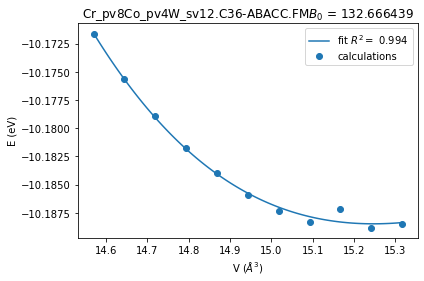

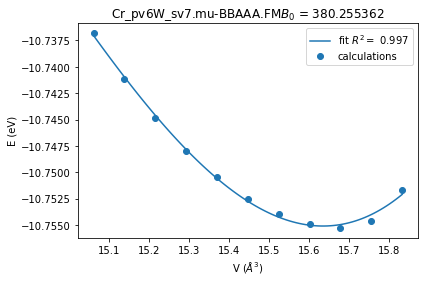

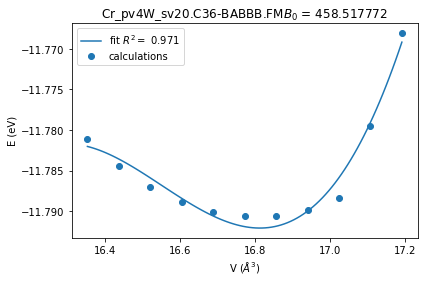

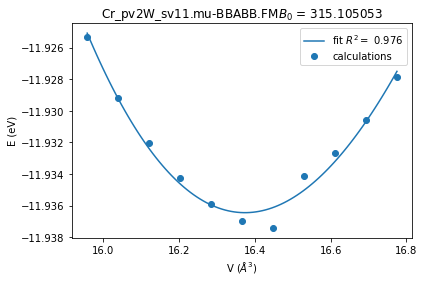

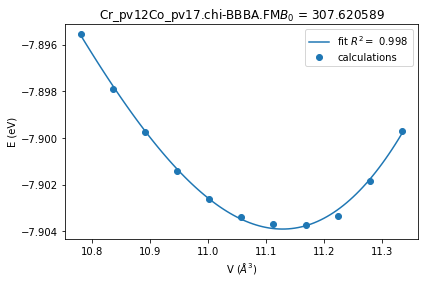

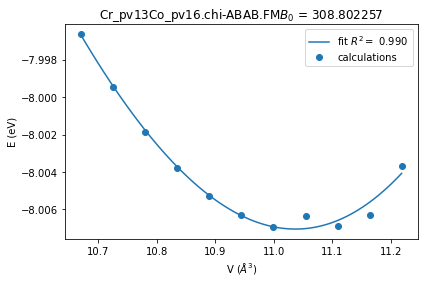

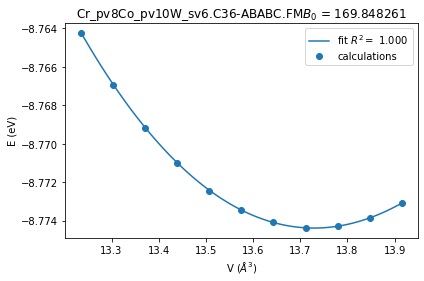

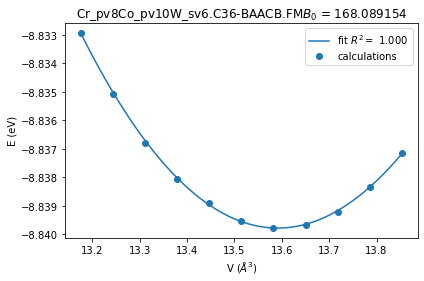

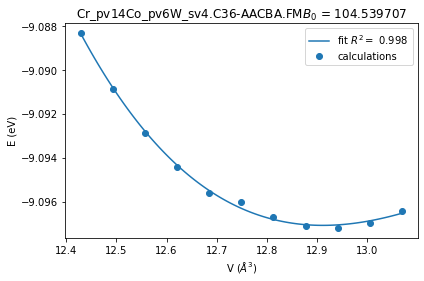

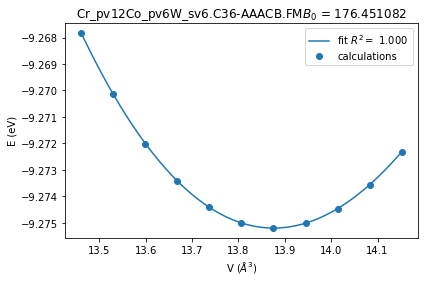

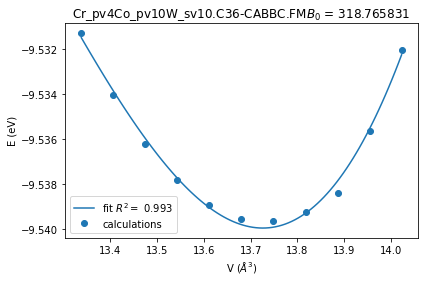

In [37]:
figurecollection, axcollection  = plot_curves(curve_high_b0, fits_high_b0, r2_high_b0)
for ax, index  in zip(axcollection, samples_high_b0):
    title=ax.get_title()
    title += f'$B_0$ = {GoodBS.B0[index]}'
    ax.set_title(title)

In [38]:
GoodBS.drop(index=samples_high_b0, inplace=True)

# Save for later use 

In [39]:
curatedbs = os.path.join(dataset,'CuratedParsedBriefSummary.pkl')
GoodBS.to_pickle(curatedbs)

<AxesSubplot:>

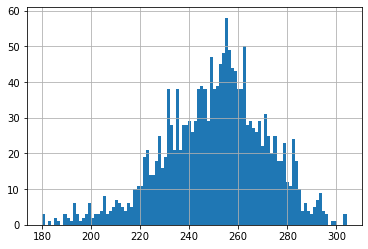

In [40]:
GoodBS.B0.hist(bins=100)